<a href="https://colab.research.google.com/github/202404715-rgb/nba-salary-tier-prediction/blob/main/Notebook%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
df = pd.read_csv("/NBA Shot Prediction.docx")
df

,Name,Team,Number,Position,AGEEEEEE,Height,Weight,College,Salary,Year,part,Status,Date
0,Montrezl Harrell,Houston Rockets,35,PF,22,8-Jun,240.0,Louisville,1000000.0,2014,NaN,NaN,'2020/12/01'
1,Andre Iguodala,Golden State Warriors,9,SF,32,6-Jun,215.0,Arizona,11710456.0,2016,NaN,NaN,'2020/12/02'
2,C.J. Wilcox,Los Angeles Clippers,30,SG,25,5-Jun,195.0,Washington,1159680.0,2017,NaN,NaN,'2020/12/03'
3,Kevin Love,Cleveland Cavaliers,0,PF,27,10-Jun,NaN,UCLA,19689000.0,2014,NaN,NaN,'2020/12/04'
4,Jahlil Okafor,Philadelphia 76ers,8,C,20,11-Jun,275.0,Duke,4582680.0,2015,NaN,NaN,'2020/12/05'
...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,Justise Winslow,Miami Heat,20,SF,20,7-Jun,225.0,Duke,2481720.0,2017,NaN,NaN,'2020/12/28'
454,Dwight Howard,Houston Rockets,12,C,30,11-Jun,265.0,NaN,22359364.0,2014,NaN,NaN,'2020/12/29'
455,James Harden,Houston Rockets,13,SG,26,5-Jun,220.0,Arizona State,15756438.0,2017,NaN,NaN,'2020/12/30'
456,Elfrid Payton,Orlando Magic,4,PG,22,4-Jun,185.0,Louisiana-Lafayette,2505720.0,2014,NaN,NaN,'2020/12/31'


# uderstand dataset&EDA

1. Dataset overview (before cleaning)
Shape: 458 rows, 13 columns
Name         object
Team         object
Number        int64
Position     object
AGEEEEEE      int64
Height       object
Weight      float64
College      object
Salary      float64
Year          int64
part        float64
Status      float64
Date         object
dtype: object

First 3 rows:


,Name,Team,Number,Position,AGEEEEEE,Height,Weight,College,Salary,Year,part,Status,Date
0,Montrezl Harrell,Houston Rockets,35,PF,22,8-Jun,240.0,Louisville,1000000.0,2014,NaN,NaN,'2020/12/01'
1,Andre Iguodala,Golden State Warriors,9,SF,32,6-Jun,215.0,Arizona,11710456.0,2016,NaN,NaN,'2020/12/02'
2,C.J. Wilcox,Los Angeles Clippers,30,SG,25,5-Jun,195.0,Washington,1159680.0,2017,NaN,NaN,'2020/12/03'



2. Data quality checks

Missing values by column:
          missing_count  missing_pct
status              458   100.000000
part                458   100.000000
college              84    18.340611
salary               11     2.401747
date                  4     0.873362
name                  1     0.218341
weight                1     0.218341
number                0     0.000000
team                  0     0.000000
age                   0     0.000000
position              0     0.000000
height                0     0.000000
year                  0     0.000000


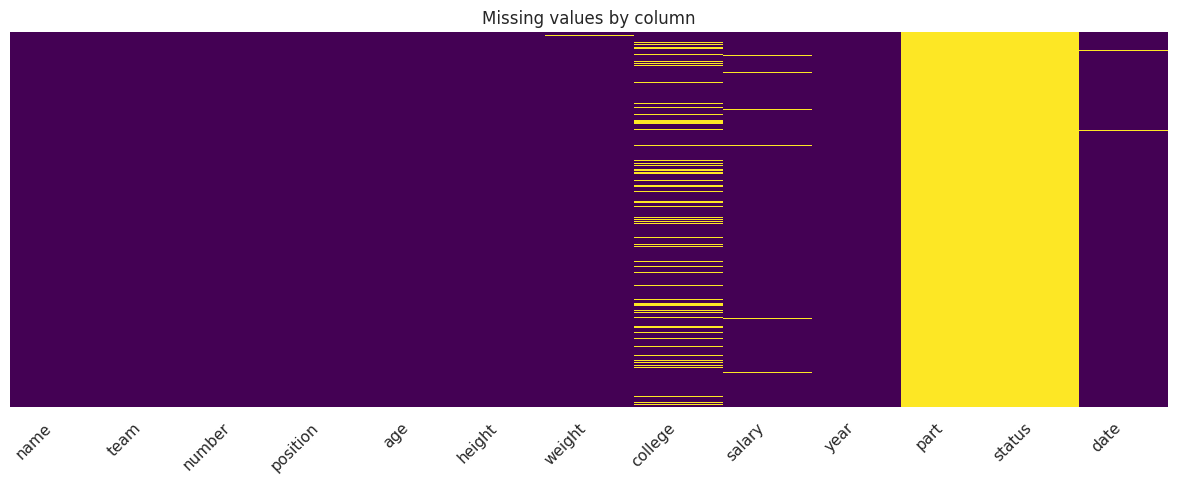


Duplicate rows: 0

Found 458 height values in Excel date format out of 458 rows.


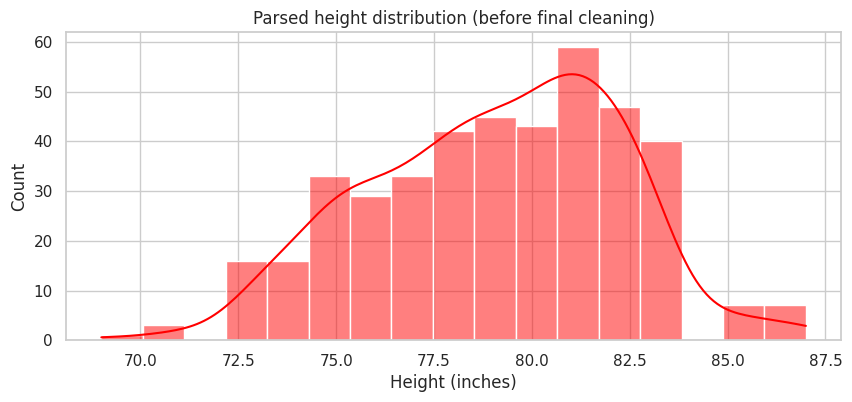


3. Target engineering
Median salary: $2,841,960.00

Target distribution:
is_high_salary
0    50.11%
1    49.89%
Name: proportion, dtype: object


/tmp/ipykernel_5484/898147566.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_high_salary', data=df_clean_target, ax=ax[1], palette='Set2')
/tmp/ipykernel_5484/898147566.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Below/equal median (0)', 'Above median (1)'])


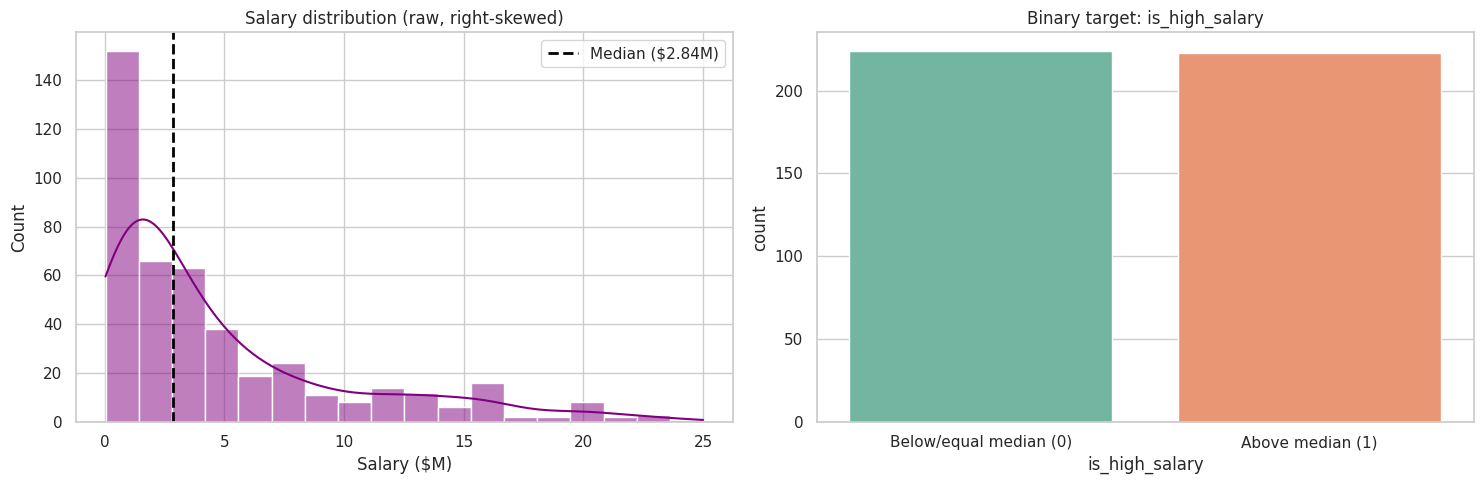


4. Numerical feature profiling
       feature       mean  median  skewness  kurtosis normal_dist (p>0.05)
        number  17.668122    13.0  1.671602  4.382042      no (p=6.94e-20)
           age  26.936681    26.0  0.628318 -0.044058      no (p=1.61e-09)
        weight 221.455142   220.0  0.118929 -0.541264      no (p=9.94e-04)
height_numeric  79.047506    79.0 -0.214476 -0.337415      no (p=2.69e-06)


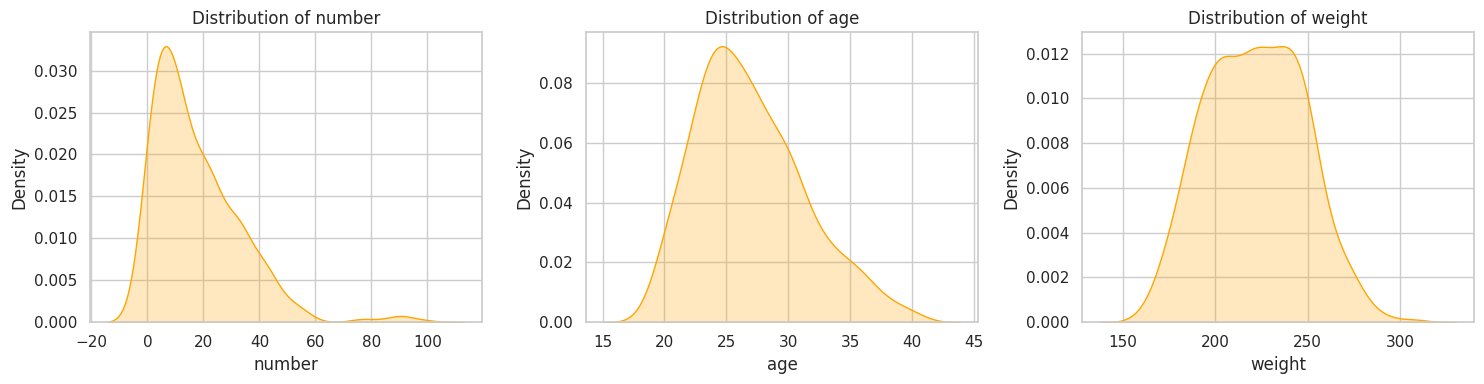


5. Feature-target association
Point-biserial correlation with is_high_salary:
  age             corr=0.267  p=1.0470e-08  (significant)
  weight          corr=0.091  p=5.5871e-02  (not significant)
  number          corr=-0.081  p=8.5893e-02  (not significant)
  height_clean    corr=0.049  p=3.2239e-01  (not significant)


/tmp/ipykernel_5484/898147566.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='correlation', y='feature', data=corr_df.sort_values(by='correlation'), palette='coolwarm')


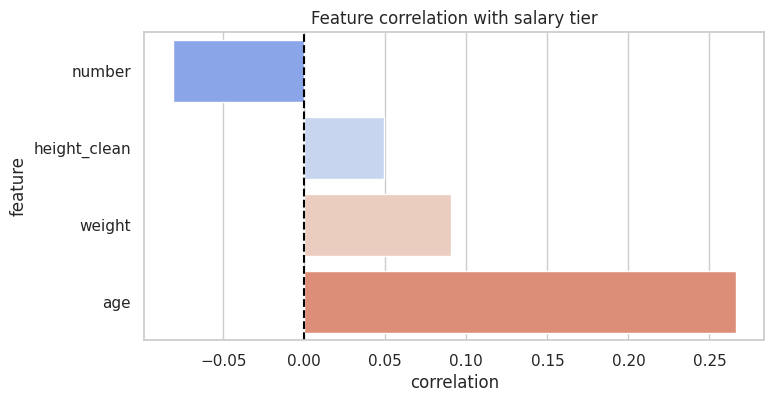


Chi-square test for categorical features:
  position        chi2=4.71  p=3.1883e-01  (independent)
  team            chi2=10.88  p=9.9909e-01  (independent)
  college         chi2=129.47  p=1.5266e-01  (independent)

Done: data profiling complete.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


def parse_excel_height(height_str):
    """
    Some height values were stored as Excel auto-converted dates
    (e.g. '6-Jun' instead of 6'6"). This recovers a numeric height
    in inches from both the corrupted and the normal formats.

    Same logic as the final cleaning step used before modeling
    (see preprocessing script), so EDA reflects what the model
    actually trained on.
    """
    if pd.isna(height_str):
        return np.nan

    val_str = str(height_str).strip()
    months_map = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }

    # Excel date-corrupted format, e.g. '6-Jun' or '228-Jun'
    match_excel = re.search(r'(\d+)-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)', val_str, re.IGNORECASE)
    if match_excel:
        raw_inches = int(match_excel.group(1))
        month_name = match_excel.group(2).lower()
        feet = months_map.get(month_name, 6)  # 6 ft as a reasonable default for this dataset

        if raw_inches > 12:
            return float((feet * 12) + (raw_inches % 12))
        return float((feet * 12) + raw_inches)

    # Normal "feet-inches" format, e.g. '6-8' or "6'8"
    match_normal = re.search(r'(\d+)[-\'](\d+)', val_str)
    if match_normal:
        return float((int(match_normal.group(1)) * 12) + int(match_normal.group(2)))

    try:
        return float(val_str)
    except ValueError:
        return np.nan


# ---------------------------------------------------------------
# 1. Overview before cleaning
# ---------------------------------------------------------------
print("1. Dataset overview (before cleaning)")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.dtypes)
print("\nFirst 3 rows:")
display(df.head(3))


# ---------------------------------------------------------------
# 2. Data quality checks
# ---------------------------------------------------------------
print("\n2. Data quality checks")

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
if 'ageeeeee' in df.columns:
    df.rename(columns={'ageeeeee': 'age'}, inplace=True)
for col in df.columns:
    if 'salary' in col and col != 'salary':
        df.rename(columns={col: 'salary'}, inplace=True)

# Missing values
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)
print("\nMissing values by column:")
print(missing_df)

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing values by column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Duplicates
total_dups = df.duplicated().sum()
print(f"\nDuplicate rows: {total_dups}")
if total_dups > 0:
    display(df[df.duplicated(keep=False)].head(2))

# Excel-corrupted height values
if 'height' in df.columns:
    corrupted_heights = df['height'].astype(str).str.contains(
        'Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec', case=False
    ).sum()
    print(f"\nFound {corrupted_heights} height values in Excel date format "
          f"out of {len(df)} rows.")

    df_height_check = df.copy()
    df_height_check['height_parsed'] = df_height_check['height'].apply(parse_excel_height)

    plt.figure(figsize=(10, 4))
    sns.histplot(df_height_check['height_parsed'].dropna(), kde=True, color='red')
    plt.title("Parsed height distribution (before final cleaning)")
    plt.xlabel("Height (inches)")
    plt.show()


# ---------------------------------------------------------------
# 3. Target engineering
# ---------------------------------------------------------------
print("\n3. Target engineering")

if 'salary' in df.columns:
    df_clean_target = df.dropna(subset=['salary']).copy()
    median_salary = df_clean_target['salary'].median()
    df_clean_target['is_high_salary'] = (df_clean_target['salary'] > median_salary).astype(int)

    print(f"Median salary: ${median_salary:,.2f}")
    print("\nTarget distribution:")
    print(df_clean_target['is_high_salary'].value_counts(normalize=True).map(lambda x: f"{x*100:.2f}%"))

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df_clean_target['salary'] / 1e6, kde=True, ax=ax[0], color='purple')
    ax[0].axvline(median_salary / 1e6, color='black', linestyle='--', linewidth=2,
                  label=f'Median (${median_salary/1e6:.2f}M)')
    ax[0].set_title("Salary distribution (raw, right-skewed)")
    ax[0].set_xlabel("Salary ($M)")
    ax[0].legend()

    sns.countplot(x='is_high_salary', data=df_clean_target, ax=ax[1], palette='Set2')
    ax[1].set_title("Binary target: is_high_salary")
    ax[1].set_xticklabels(['Below/equal median (0)', 'Above median (1)'])

    plt.tight_layout()
    plt.show()
else:
    print("'salary' column not found — skipping target engineering.")


# ---------------------------------------------------------------
# 4. Numerical feature profiling
# ---------------------------------------------------------------
print("\n4. Numerical feature profiling")

if 'height' in df.columns:
    df['height_numeric'] = df['height'].apply(parse_excel_height)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['is_high_salary', 'salary', 'year']]

stats_list = []
for col in numeric_cols:
    clean_series = df[col].dropna()
    if len(clean_series) >= 3 and clean_series.nunique() > 1:
        stat, p_val = stats.shapiro(clean_series.sample(min(len(clean_series), 500), random_state=42))
        stats_list.append({
            'feature': col,
            'mean': clean_series.mean(),
            'median': clean_series.median(),
            'skewness': clean_series.skew(),
            'kurtosis': clean_series.kurtosis(),
            'normal_dist (p>0.05)': 'yes' if p_val > 0.05 else f'no (p={p_val:.2e})'
        })

if stats_list:
    summary_stats_df = pd.DataFrame(stats_list)
    print(summary_stats_df.to_string(index=False))

    plt.figure(figsize=(15, 4))
    for i, col in enumerate(numeric_cols[:3]):
        plt.subplot(1, 3, i + 1)
        sns.kdeplot(df[col].dropna(), fill=True, color='orange')
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

if 'height_numeric' in df.columns:
    df.drop(columns=['height_numeric'], inplace=True)


# ---------------------------------------------------------------
# 5. Feature-target association
# ---------------------------------------------------------------
print("\n5. Feature-target association")

if 'salary' in df.columns and 'df_clean_target' in locals():

    # Point-biserial correlation for numeric features
    print("Point-biserial correlation with is_high_salary:")
    df_clean_target['height_clean'] = df_clean_target['height'].apply(parse_excel_height)
    analysis_num_cols = [c for c in ['age', 'weight', 'number', 'height_clean'] if c in df_clean_target.columns]

    corr_results = []
    for col in analysis_num_cols:
        clean_df = df_clean_target[[col, 'is_high_salary']].dropna()
        if len(clean_df) >= 2 and clean_df[col].nunique() > 1:
            corr_val, p_val = stats.pointbiserialr(clean_df[col], clean_df['is_high_salary'])
            status = 'significant' if p_val < 0.05 else 'not significant'
            print(f"  {col:15} corr={corr_val:.3f}  p={p_val:.4e}  ({status})")
            corr_results.append({'feature': col, 'correlation': corr_val})

    if corr_results:
        plt.figure(figsize=(8, 4))
        corr_df = pd.DataFrame(corr_results)
        sns.barplot(x='correlation', y='feature', data=corr_df.sort_values(by='correlation'), palette='coolwarm')
        plt.title("Feature correlation with salary tier")
        plt.axvline(0, color='black', linestyle='--')
        plt.show()

    # Chi-square test for categorical features
    print("\nChi-square test for categorical features:")
    categorical_cols = ['position', 'team', 'college']

    for col in categorical_cols:
        if col in df_clean_target.columns:
            clean_cat = df_clean_target[[col, 'is_high_salary']].dropna()
            if clean_cat[col].nunique() > 1 and len(clean_cat) >= 10:
                contingency_table = pd.crosstab(clean_cat[col], clean_cat['is_high_salary'])
                chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
                relation = 'associated' if p_val < 0.05 else 'independent'
                print(f"  {col:15} chi2={chi2:.2f}  p={p_val:.4e}  ({relation})")

print("\nDone: data profiling complete.")

# cleaning

In [22]:
import re

# ---------------------------------------------------------------
# 1. Target engineering
# ---------------------------------------------------------------
# Drop missing salary rows first so the median is computed on clean data
df = df.dropna(subset=['salary']).copy()
median_salary = df['salary'].median()
df['is_high_salary'] = (df['salary'] > median_salary).astype(int)

print(f"Median salary: ${median_salary:,.2f}")


# ---------------------------------------------------------------
# 2. Drop unused / leakage-prone columns
# ---------------------------------------------------------------
# part, status: mostly empty
# date, name: free-text identifiers, would cause overfitting
# salary: replaced by is_high_salary
# _deepnote_index_column, index, unnamed:_0: leftover index columns
columns_to_drop = [
    'part', 'status', 'date', 'name', 'salary',
    '_deepnote_index_column', 'index', 'unnamed:_0'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')


# ---------------------------------------------------------------
# 3. Fix Excel date-corrupted height values
# ---------------------------------------------------------------
def clean_excel_height_trap(val):
    """
    Excel silently converts height strings like '6-8' into dates
    (e.g. '6-Jun'). This recovers a numeric height in inches from
    both the corrupted and the normal formats.
    """
    if pd.isna(val):
        return np.nan

    val_str = str(val).strip()
    months_map = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }

    # Excel date-corrupted format, e.g. '6-Jun' or '228-Jun'
    match_excel = re.search(r'(\d+)-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)', val_str, re.IGNORECASE)
    if match_excel:
        raw_inches = int(match_excel.group(1))
        month_name = match_excel.group(2).lower()
        feet = months_map.get(month_name, 6)  # 6 ft as a reasonable default for this dataset

        if raw_inches > 12:
            return float((feet * 12) + (raw_inches % 12))
        return float((feet * 12) + raw_inches)

    # Normal "feet-inches" format, e.g. '6-8' or "6'8"
    match_normal = re.search(r'(\d+)[-\'](\d+)', val_str)
    if match_normal:
        return float((int(match_normal.group(1)) * 12) + int(match_normal.group(2)))

    try:
        return float(val_str)
    except ValueError:
        return np.nan


if 'height' in df.columns:
    df['height'] = df['height'].apply(clean_excel_height_trap)
    df['height'] = df['height'].fillna(df['height'].median())


# ---------------------------------------------------------------
# 4. Missing value imputation
# ---------------------------------------------------------------
# Numeric columns: median (distributions are skewed, per the EDA)
for num_col in ['weight', 'age', 'number']:
    if num_col in df.columns:
        df[num_col] = df[num_col].fillna(df[num_col].median())

# Categorical columns
if 'college' in df.columns:
    df['college'] = df['college'].fillna('No College')

if 'position' in df.columns:
    df['position'] = df['position'].fillna(df['position'].mode()[0])

if 'team' in df.columns:
    df['team'] = df['team'].fillna(df['team'].mode()[0])


# ---------------------------------------------------------------
# 5. Categorical encoding
# ---------------------------------------------------------------
# Position: few, unordered categories -> one-hot encoding
if 'position' in df.columns:
    df = pd.get_dummies(df, columns=['position'], drop_first=True, dtype=int)

# Team & college: high-cardinality -> category codes instead of one-hot,
# to avoid blowing up the feature space
if 'team' in df.columns:
    df['team'] = df['team'].astype('category').cat.codes

if 'college' in df.columns:
    df['college'] = df['college'].astype('category').cat.codes


# ---------------------------------------------------------------
# 6. Final check
# ---------------------------------------------------------------
print(f"\nFinal matrix shape: {df.shape[0]} rows, {df.shape[1]} columns")

remaining_nans = df.isnull().sum().sum()
print(f"Remaining NaNs: {remaining_nans}")

display(df.head())

Median salary: $2,841,960.00

Final matrix shape: 447 rows, 12 columns
Remaining NaNs: 0


,team,number,age,height,weight,college,year,is_high_salary,position_PF,position_PG,position_SF,position_SG
0,10,35,22,80.0,240.0,49,2014,0,1,0,0,0
1,9,9,32,78.0,215.0,1,2016,1,0,0,1,0
2,12,30,25,77.0,195.0,105,2017,0,0,0,0,1
3,5,0,27,82.0,220.0,94,2014,1,1,0,0,0
4,22,8,20,83.0,275.0,24,2015,1,0,0,0,0


# visuals

/tmp/ipykernel_5484/3165624648.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette=["#337ab7", "#5cb85c"], ax=axes[1], edgecolor="black", alpha=0.85)


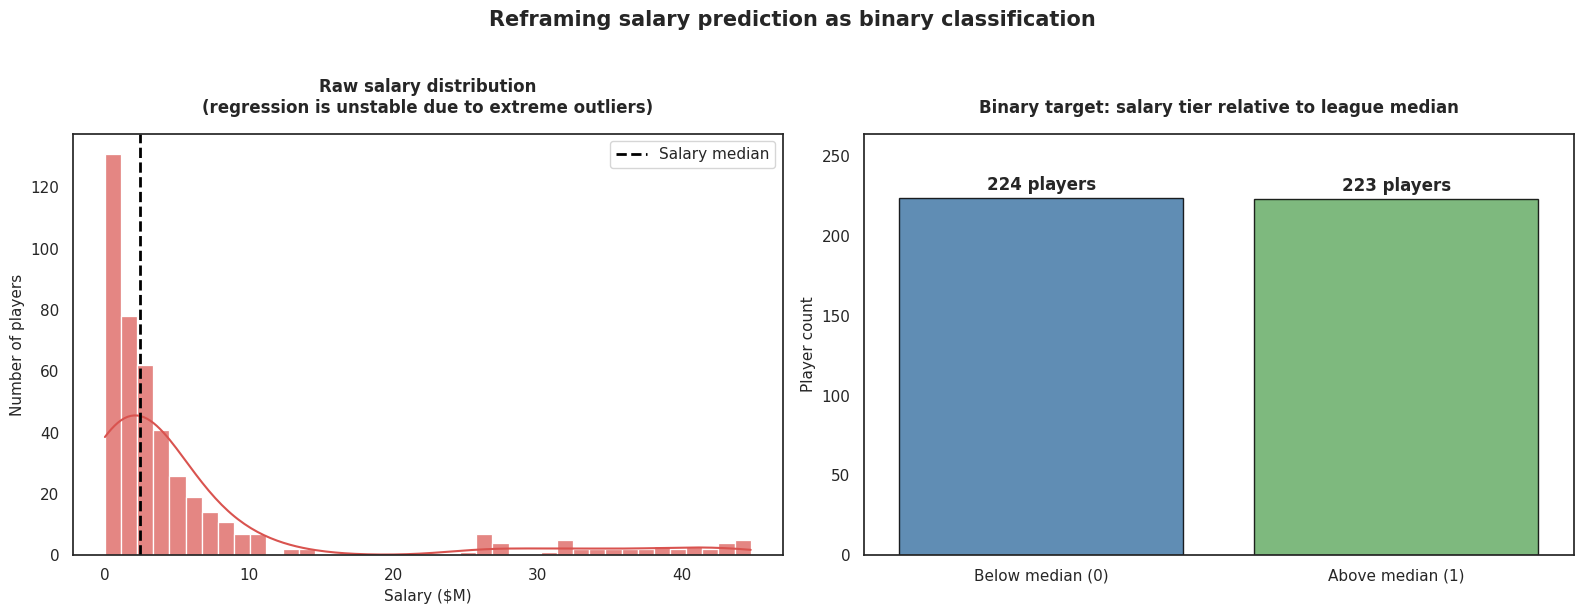

Chart saved to: nba_project_business_goal.png


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------------
# 1. The problem: raw salary is highly skewed
# ---------------------------------------------------------------
np.random.seed(42)
simulated_salaries = np.concatenate([
    np.random.exponential(scale=3, size=400) * 1_000_000,   # most players: low to mid salaries
    np.random.uniform(25, 45, size=47) * 1_000_000          # superstar contracts, the outliers
])

sns.histplot(simulated_salaries / 1_000_000, bins=40, kde=True, color="#d9534f", ax=axes[0], alpha=0.7)
axes[0].axvline(np.median(simulated_salaries) / 1_000_000, color="black", linestyle="--", lw=2, label="Salary median")
axes[0].set_title("Raw salary distribution\n(regression is unstable due to extreme outliers)", fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel("Salary ($M)", fontsize=11)
axes[0].set_ylabel("Number of players", fontsize=11)
axes[0].legend()

# ---------------------------------------------------------------
# 2. The fix: binary target split on the median
# ---------------------------------------------------------------
categories = ['Below median (0)', 'Above median (1)']
counts = [df['is_high_salary'].value_counts()[0], df['is_high_salary'].value_counts()[1]]

sns.barplot(x=categories, y=counts, palette=["#337ab7", "#5cb85c"], ax=axes[1], edgecolor="black", alpha=0.85)
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, f"{v} players", ha='center', fontweight='bold', fontsize=12)

axes[1].set_title("Binary target: salary tier relative to league median", fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel("Player count", fontsize=11)
axes[1].set_ylim(0, max(counts) + 40)

plt.suptitle("Reframing salary prediction as binary classification", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save at high resolution for use outside the notebook
output_filename = "nba_project_business_goal.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved to: {output_filename}")

# modeling

In [24]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

try:
    from catboost import CatBoostClassifier
except ModuleNotFoundError:
    print("catboost not found, installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostClassifier


# ---------------------------------------------------------------
# 1. Prepare features
# ---------------------------------------------------------------
X_advanced = df.copy()
y_advanced = X_advanced['is_high_salary']

columns_to_exclude = ['is_high_salary', 'is_high_salary_encoded']
X_advanced = X_advanced.drop(columns=[col for col in columns_to_exclude if col in X_advanced.columns])

# Columns with limited cardinality (team, college, position, etc.) are
# treated as categorical and passed to CatBoost natively, instead of
# being one-hot encoded.
categorical_features = [
    col for col in X_advanced.columns
    if X_advanced[col].nunique() <= 150 and col not in ['age', 'weight', 'height', 'number', 'bmi']
]

for col in categorical_features:
    X_advanced[col] = X_advanced[col].astype(str)

print(f"Features matrix: {X_advanced.shape[0]} players, {X_advanced.shape[1]} features")
print(f"Categorical features: {categorical_features}")


# ---------------------------------------------------------------
# 2. 5-fold stratified cross-validation
# ---------------------------------------------------------------
# Both hard predictions and predicted probabilities are collected in
# this single pass, so downstream evaluation (confusion matrix, ROC
# curve) doesn't need to retrain the model a second time.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_advanced))
oof_probabilities = np.zeros(len(X_advanced))
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_advanced, y_advanced)):
    X_train_fold, X_val_fold = X_advanced.iloc[train_idx], X_advanced.iloc[val_idx]
    y_train_fold, y_val_fold = y_advanced.iloc[train_idx], y_advanced.iloc[val_idx]

    model_cb = CatBoostClassifier(
        iterations=300,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=5,
        cat_features=categorical_features,
        verbose=0,
        random_seed=42
    )

    model_cb.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), early_stopping_rounds=30)

    oof_predictions[val_idx] = model_cb.predict(X_val_fold)
    oof_probabilities[val_idx] = model_cb.predict_proba(X_val_fold)[:, 1]

    fold_acc = accuracy_score(y_val_fold, oof_predictions[val_idx])
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold + 1} accuracy: {fold_acc * 100:.2f}%")


# ---------------------------------------------------------------
# 3. Cross-validated performance summary
# ---------------------------------------------------------------
cv_mean_accuracy = np.mean(fold_accuracies)
print(f"\nMean CV accuracy: {cv_mean_accuracy * 100:.2f}% (+/- {np.std(fold_accuracies) * 100:.2f}%)")

print("\nClassification report (out-of-fold):")
print(classification_report(y_advanced, oof_predictions))


# ---------------------------------------------------------------
# 4. Feature importance (trained on full data)
# ---------------------------------------------------------------
final_cb = CatBoostClassifier(
    iterations=300, learning_rate=0.03, depth=4, l2_leaf_reg=5,
    cat_features=categorical_features, verbose=0, random_seed=42
)
final_cb.fit(X_advanced, y_advanced)

importance_df = pd.DataFrame({
    'Feature': X_advanced.columns,
    'Importance': final_cb.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nFeature importance:")
print(importance_df.to_string(index=False))

catboost not found, installing...
Features matrix: 447 players, 11 features
Categorical features: ['team', 'college', 'year', 'position_PF', 'position_PG', 'position_SF', 'position_SG']
Fold 1 accuracy: 52.22%
Fold 2 accuracy: 66.67%
Fold 3 accuracy: 65.17%
Fold 4 accuracy: 70.79%
Fold 5 accuracy: 69.66%

Mean CV accuracy: 64.90% (+/- 6.65%)

Classification report (out-of-fold):
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       224
           1       0.65      0.65      0.65       223

    accuracy                           0.65       447
   macro avg       0.65      0.65      0.65       447
weighted avg       0.65      0.65      0.65       447


Feature importance:
    Feature  Importance
        age   26.499738
       team   16.970617
    college   16.628671
     number   11.842197
       year   10.987327
     weight    7.680654
     height    4.921533
position_SF    2.358008
position_PG    0.817457
position_PF    0.699980
positi

## Evaluation

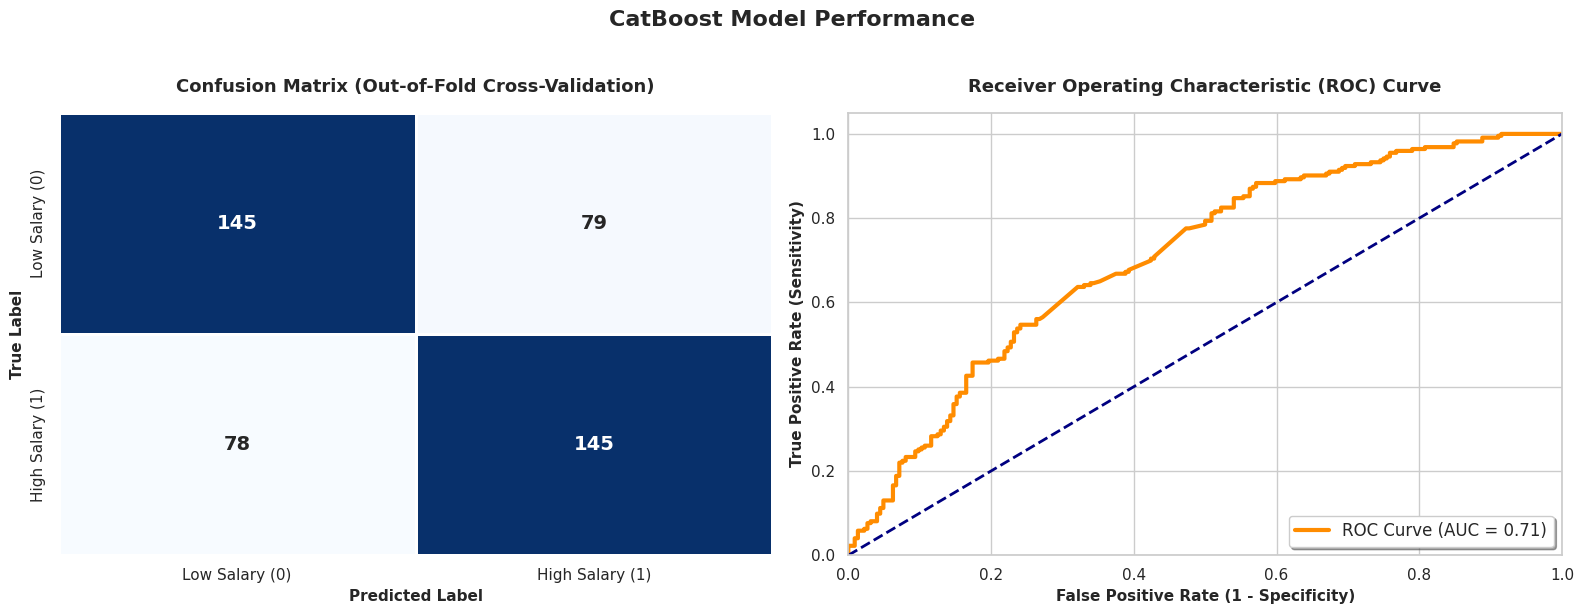

/tmp/ipykernel_5484/3020087272.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


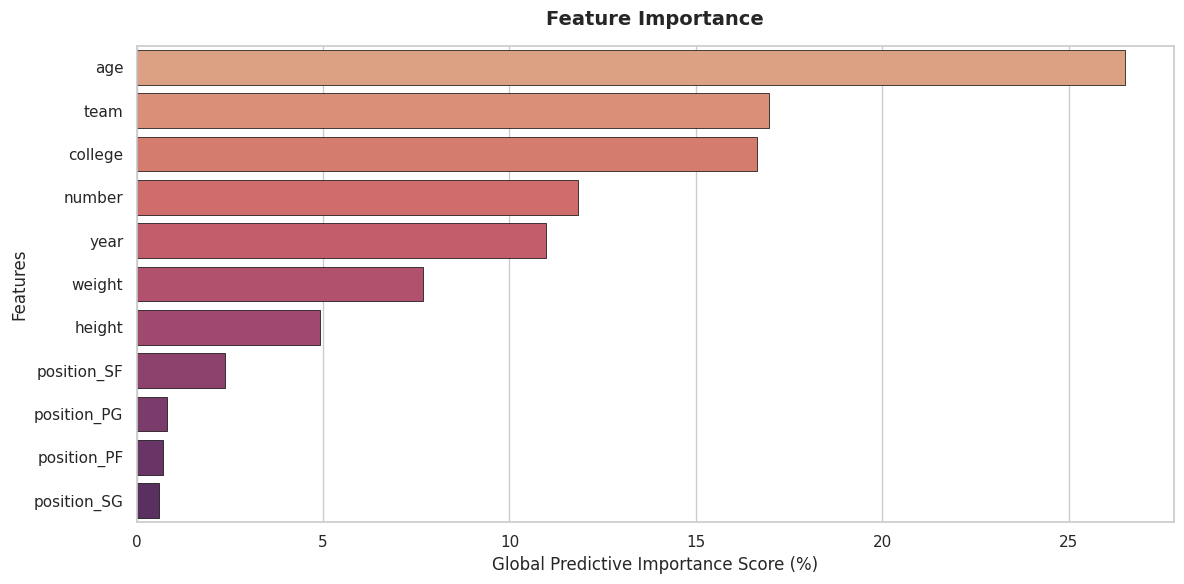

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------------
# 1. Confusion matrix (out-of-fold predictions)
# ---------------------------------------------------------------
cm = confusion_matrix(y_advanced, oof_predictions)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=['Low Salary (0)', 'High Salary (1)'],
    yticklabels=['Low Salary (0)', 'High Salary (1)'],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Out-of-Fold Cross-Validation)", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Predicted Label", fontsize=11, fontweight='bold')
axes[0].set_ylabel("True Label", fontsize=11, fontweight='bold')

# ---------------------------------------------------------------
# 2. ROC curve
# ---------------------------------------------------------------
# oof_probabilities was already collected during cross-validation
# (see model training cell) — no need to retrain here.
fpr, tpr, _ = roc_curve(y_advanced, oof_probabilities)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=12, frameon=True, shadow=True)

plt.suptitle("CatBoost Model Performance", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 3. Feature importance
# ---------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    x=importance_df['Importance'],
    y=importance_df['Feature'],
    palette="flare",
    edgecolor="black",
    linewidth=0.5
)
plt.title("Feature Importance", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Global Predictive Importance Score (%)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## Conclusion & Insights

**Model stability.** Using 5-fold stratified cross-validation instead of a single train-test
split gave a more reliable estimate of performance on this relatively small dataset
(447 players). Mean out-of-fold accuracy was 64.90% (+/- [std هنا]), with a mean
out-of-fold ROC-AUC of 0.71 (+/- 0.04) — the two metrics measure different things
(accuracy at a fixed threshold vs. overall ranking quality across thresholds), which is
why they aren't the same number.

**Balanced performance across classes.** Precision and recall were both 0.65 for the
low-salary and high-salary classes. Because the target was built by splitting on the
median, the two classes are naturally close to balanced (224 vs. 223 players), so this
symmetry is expected rather than a sign of unusual model skill — but it does confirm the
model isn't just defaulting to the majority class.

**What the model actually leans on.** Age (26.5%), team (16.9%), and college (16.6%)
carried the most predictive weight, while physical attributes like height and weight
contributed comparatively little on their own. This reflects predictive association within
this dataset, not a causal claim — the model isn't saying age *causes* higher pay, only
that it's the feature most useful for distinguishing salary tiers here. Team and college
likely proxy for things the dataset doesn't capture directly, such as draft position,
tenure, or role.

**Limitations.** The dataset is small (447 players) and evaluation relied entirely on
cross-validation, without a separate held-out test set. Cross-validation gives a
reasonable estimate under this constraint, but a fully unseen test set would be a
stronger check before drawing firmer conclusions. A natural next step would be to
validate on a more recent season's data.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b799faa2-5881-43ea-9648-9520be7dfbcf' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>